In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0)

In [2]:
cars = pd.read_csv("prepared_car_sales.csv")
np.random.seed(1)

In [3]:
cars.info()
print(cars.describe())
print(cars.shape)
cars.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14430 entries, 0 to 14429
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Index                    14430 non-null  int64  
 1   Price                    14430 non-null  int64  
 2   Currency                 14430 non-null  object 
 3   Condition                14430 non-null  object 
 4   Vehicle_brand            14430 non-null  object 
 5   Vehicle_model            14430 non-null  object 
 6   Vehicle_version          9887 non-null   object 
 7   Vehicle_generation       10212 non-null  object 
 8   Production_year          14430 non-null  int64  
 9   Mileage_km               14430 non-null  float64
 10  Power_HP                 14389 non-null  float64
 11  Displacement_cm3         14287 non-null  float64
 12  Fuel_type                14430 non-null  object 
 13  CO2_emissions            6536 non-null   float64
 14  Drive                 

Index(['Index', 'Price', 'Currency', 'Condition', 'Vehicle_brand',
       'Vehicle_model', 'Vehicle_version', 'Vehicle_generation',
       'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3',
       'Fuel_type', 'CO2_emissions', 'Drive', 'Transmission', 'Type',
       'Doors_number', 'Colour', 'Origin_country', 'First_owner',
       'First_registration_date', 'Offer_publication_date', 'Offer_location',
       'Features'],
      dtype='object')

array([[<Axes: title={'center': 'Index'}>,
        <Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Production_year'}>],
       [<Axes: title={'center': 'Mileage_km'}>,
        <Axes: title={'center': 'Power_HP'}>,
        <Axes: title={'center': 'Displacement_cm3'}>],
       [<Axes: title={'center': 'CO2_emissions'}>,
        <Axes: title={'center': 'Doors_number'}>, <Axes: >]], dtype=object)

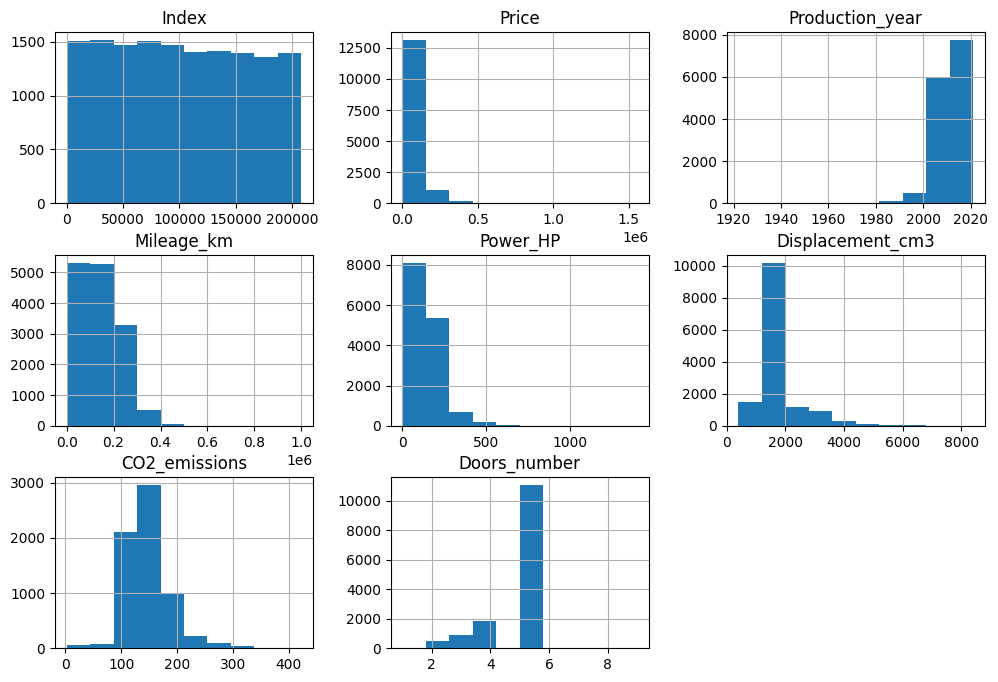

In [4]:
cars.hist(figsize=(12, 8))

In [5]:
from sklearn.model_selection import train_test_split

train_set_df, test_set_df = train_test_split(cars, test_size=0.15 , random_state=0)
labels = train_set_df['Price']
test_labels = test_set_df['Price']

#train_set = train_set.drop(columns=['Price'])
#test_set = test_set.drop(columns=['Price'])

### Data analysis

In [6]:
tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
for i, row in tmp_df.iterrows():
    if row['Currency'] == 'EUR':
        tmp_df.at[i, 'Price'] = row['Price'] * 4.26
tmp_df = tmp_df.drop(columns='Currency')
tmp_df['Condition'] = tmp_df['Condition'].map({'Used': 0, 'New': 1})
corr_mtx = tmp_df.corr()
corr_mtx['Price'].sort_values(ascending=False)

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\1385475858.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8051.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  tmp_df.at[i, 'Price'] = row['Price'] * 4.26


Price              1.000000
Power_HP           0.628924
Condition          0.444234
Production_year    0.410088
CO2_emissions      0.188188
Mileage_km        -0.505205
Name: Price, dtype: float64

In [7]:
dummies = pd.get_dummies(train_set_df['Vehicle_brand'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
corrs.sort_values(ascending=False).head(10)

Porsche          0.187021
Ferrari          0.157980
McLaren          0.153468
Bentley          0.139778
Lamborghini      0.133244
BMW              0.133079
Mercedes-Benz    0.125778
Land Rover       0.118499
Rolls-Royce      0.114679
Audi             0.075250
dtype: float64

In [8]:
# print(train_set['Type'].unique())
# print(train_set['Transmission'].unique())

dummies = pd.get_dummies(train_set_df['Type'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False), '\n')

dummies = pd.get_dummies(train_set_df['Transmission'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False))

SUV              0.288929
coupe            0.131827
sedan            0.063268
convertible      0.047107
small_cars      -0.077725
minivan         -0.087670
station_wagon   -0.088786
compact         -0.116980
city_cars       -0.156929
dtype: float64 

Automatic    0.472969
Manual      -0.471245
dtype: float64


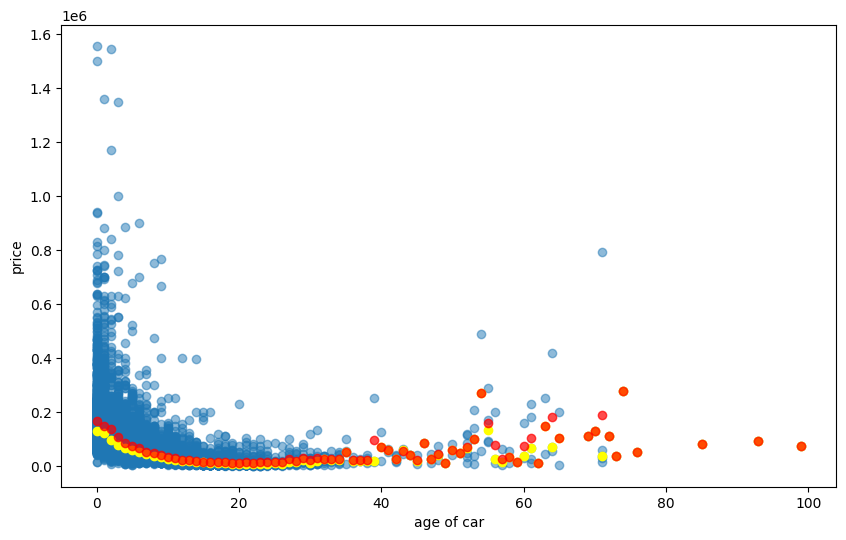

In [9]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']
avg_prices = tmp_df.groupby('Years')['Price'].mean()
median_prices = tmp_df.groupby('Years')['Price'].median()
axis.scatter(tmp_df['Years'], tmp_df['Price'], alpha=0.5)
axis.scatter(median_prices.index, median_prices, c='yellow', alpha=1)
axis.scatter(avg_prices.index, avg_prices, c='red', alpha=0.7)
tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='age of car')
axis.set_ylabel(ylabel='price')
plt.show()

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\2821282248.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\2821282248.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()


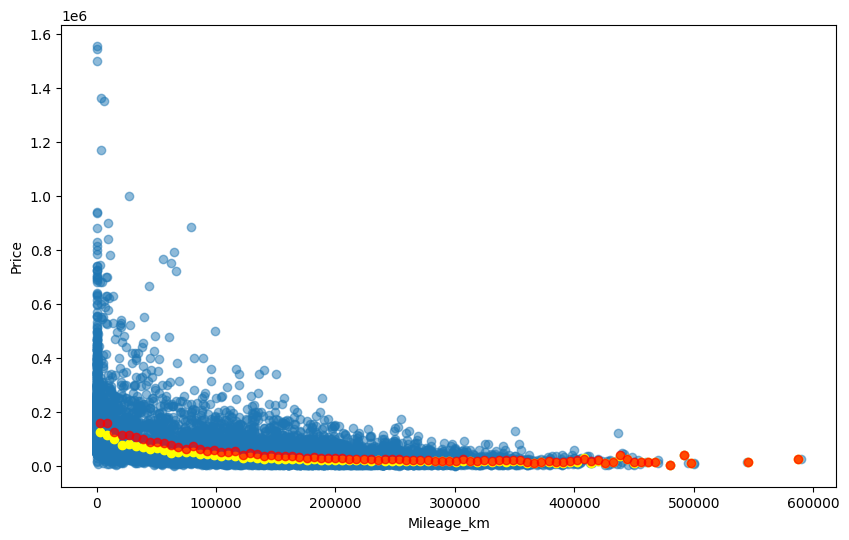

In [10]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=100)
indexes = (lin[:-1] + lin[1:]) / 2

tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()
# print(avg_prices)
# print(median_prices)
axis.scatter(tmp_df['Mileage_km'], tmp_df['Price'], alpha=0.5)
axis.scatter(indexes, median_prices['Price'], c='yellow', alpha=1)
axis.scatter(indexes, avg_prices['Price'], c='red', alpha=0.7)
# tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='Mileage_km')
axis.set_ylabel(ylabel='Price')
plt.show()

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\3465555353.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\3465555353.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()


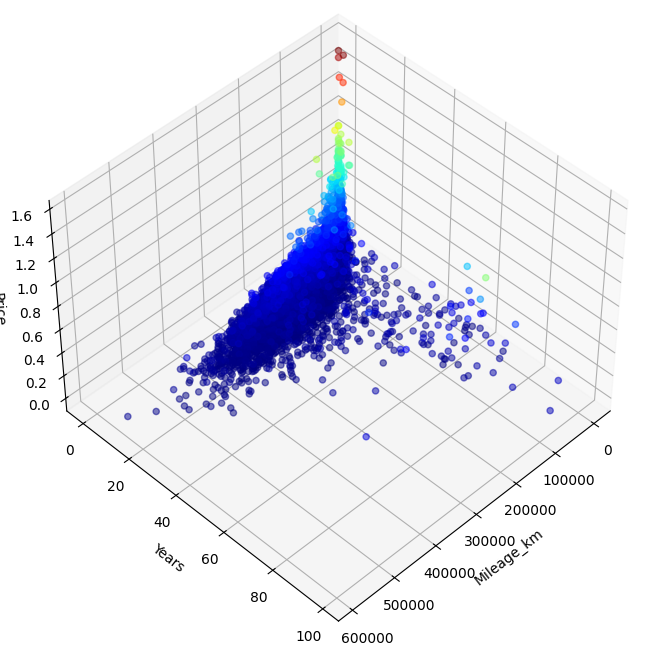

In [11]:
fig = plt.figure(figsize=(12, 8))
axis = plt.axes(projection='3d')

tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']
lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=200)
indexes = (lin[:-1] + lin[1:]) / 2

tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()

axis.scatter(tmp_df['Mileage_km'], tmp_df['Years'], tmp_df['Price'], alpha=0.5,
             c=tmp_df['Price'], cmap='jet') #viridis, jet
axis.view_init(azim=45, elev=45)

axis.set_xlabel(xlabel='Mileage_km')
axis.set_ylabel(ylabel='Years')
axis.set_zlabel(zlabel='Price')

plt.show()

### Pipeline

In [12]:
def currency_conversion(row, rules: dict):
    if row['Currency'] in rules:
        row['Price'] = row['Price'] * rules[row['Currency']]
    return row

from sklearn.base import BaseEstimator, TransformerMixin

class ExclusiveCars(BaseEstimator, TransformerMixin):
    def __init__(self, brand_col, ex_cars):
        self.brand_col = brand_col
        self.ex_cars = ex_cars
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X).copy()
        X[:, self.brand_col] = np.isin(X[:, self.brand_col], list(self.ex_cars)).astype(int)
        return X



In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler

num_attributes = ['Years', 'Mileage_km', 'Power_HP', 'CO2_emissions', 'Vehicle_brand']
cat_attributes = ['Condition', 'Transmission', 'Type']

"""
Used     Automatic     SUV   
New      Manual        coupe
                       sedan        
                       convertible  
                       small_cars   
                       minivan      
                       station_wagon
                       compact      
                       city_cars    
"""

ex_cars = [
    "Porsche",
    "Ferrari",
    "McLaren",
    "Bentley",
    "Lamborghini",
    "BMW",
    "Mercedes-Benz",
    "Land Rover",
    "Rolls-Royce"
]

#Axis 0 will act on all the ROWS in each COLUMN
#Axis 1 will act on all the COLUMNS in each ROW
train_set_df.apply(lambda row: currency_conversion(row, {'EUR': 4.26}), axis=1)
train_set_df['Years'] = 2022 - train_set_df['Production_year']

######################TEST SETS###########################
test_set_df.apply(lambda row: currency_conversion(row, {'EUR': 4.26}), axis=1)
test_set_df['Years'] = 2022 - test_set_df['Production_year']


num_pipeline = Pipeline([
    ('exclusive-cars', ExclusiveCars(num_attributes.index('Vehicle_brand'), ex_cars)),
    ('imputer', SimpleImputer(strategy='median')),
    #('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one-hot-encoder', OneHotEncoder()),
])

final_pipeline = ColumnTransformer(transformers= [
    ('nums', num_pipeline, num_attributes),
    ('cats', cat_pipeline, cat_attributes),
],
remainder='drop',
n_jobs=-1,
)

train_set = final_pipeline.fit_transform(train_set_df)
test_set = final_pipeline.fit_transform(test_set_df)

### test outlinerów

Rozmiar oryginału: 12265 rozmiar po oczyszczeniu: 12019


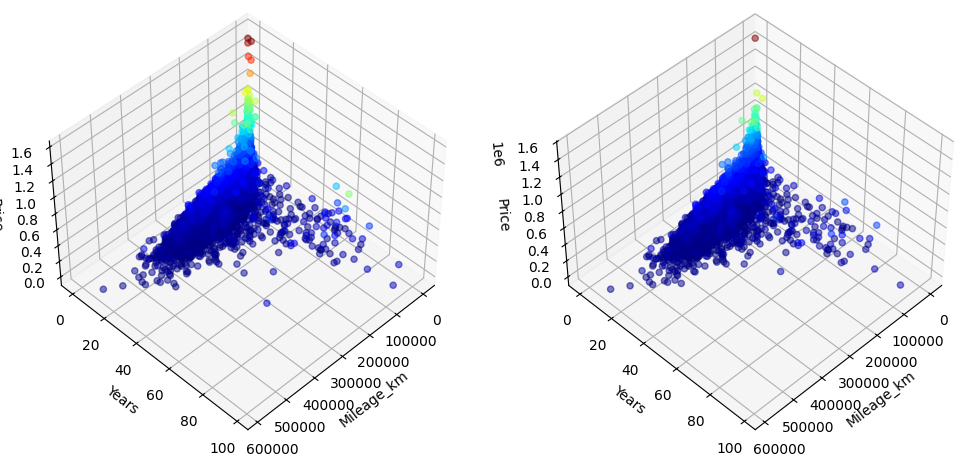

In [56]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.02,
    random_state=42
)

iso.fit(train_set)
is_outliner = iso.predict(train_set)


#-----------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 8),
    subplot_kw={'projection': '3d'}
)

ax1, ax2 = axes

tmp_df = train_set_df[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']

tmp_df['is_outlier'] = is_outliner == -1
tmp_df_clean = tmp_df[~tmp_df['is_outlier']].drop(columns='is_outlier').reset_index(drop=True)
print("Rozmiar oryginału:", len(tmp_df), "rozmiar po oczyszczeniu:", len(tmp_df_clean))

lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=200)
indexes = (lin[:-1] + lin[1:]) / 2
tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
ax1.scatter(tmp_df['Mileage_km'], tmp_df['Years'], tmp_df['Price'], alpha=0.5,
             c=tmp_df['Price'], cmap='jet') #viridis, jet
ax1.view_init(azim=45, elev=45)
ax1.set_xlabel(xlabel='Mileage_km')
ax1.set_ylabel(ylabel='Years')
ax1.set_zlabel(zlabel='Price')

#----------------------------

lin = np.linspace(start=0, stop=tmp_df_clean['Mileage_km'].max(), num=200)
indexes = (lin[:-1] + lin[1:]) / 2
tmp_df_clean['mileage_group'] = pd.cut(tmp_df_clean['Mileage_km'], bins=lin)
ax2.scatter(tmp_df_clean['Mileage_km'], tmp_df_clean['Years'], tmp_df_clean['Price'], alpha=0.5,
             c=tmp_df_clean['Price'], cmap='jet') #viridis, jet
ax2.view_init(azim=45, elev=45)
ax2.set_xlabel(xlabel='Mileage_km')
ax2.set_ylabel(ylabel='Years')
ax2.set_zlabel(zlabel='Price')
plt.show()

In [57]:
train_set_clean = train_set[is_outliner == 1]
labels_clean = labels[is_outliner == 1]
print(len(train_set_clean))
print(len(labels_clean))

12019
12019


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_attributes = ['Years', 'Mileage_km', 'Power_HP', 'CO2_emissions']
cat_attributes = ['Condition', 'Transmission', 'Type', 'Vehicle_brand']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('exclusive-cars', ExclusiveCars(cat_attributes.index('Vehicle_brand'), ex_cars)),
])

final_pipeline = ColumnTransformer(transformers= [
    ('nums', num_pipeline, num_attributes),
    ('cats', cat_pipeline, cat_attributes),
],
remainder='drop',
n_jobs=-1,
)

catboost_train_set = final_pipeline.fit_transform(train_set_df)
catboost_test_set = final_pipeline.fit_transform(test_set_df)

print(catboost_train_set[0])

from catboost import CatBoostRegressor

model = CatBoostRegressor(cat_features=[4, 5, 6, 7])
model.fit(catboost_train_set, labels)
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape
final_mse = mean_squared_error(test_labels, model.predict(catboost_test_set))
print(np.sqrt(final_mse))
print('Accuracy = {:0.2f}%.'.format(1-mape(test_labels, model.predict(catboost_test_set))))


[11.0 156000.0 116.0 140.0 'Used' 'Manual' 'minivan' 0]
Learning rate set to 0.06084
0:	learn: 83392.1572572	total: 22.1ms	remaining: 22.1s
1:	learn: 80032.7114114	total: 47ms	remaining: 23.4s
2:	learn: 76895.5226432	total: 69.3ms	remaining: 23s
3:	learn: 73826.3276648	total: 95.9ms	remaining: 23.9s
4:	learn: 70919.4499873	total: 120ms	remaining: 24s
5:	learn: 68318.6636604	total: 145ms	remaining: 24s
6:	learn: 65938.5027413	total: 170ms	remaining: 24.1s
7:	learn: 63621.3580121	total: 195ms	remaining: 24.2s
8:	learn: 61341.2245255	total: 220ms	remaining: 24.3s
9:	learn: 59395.0920362	total: 245ms	remaining: 24.3s
10:	learn: 57547.8004535	total: 269ms	remaining: 24.2s
11:	learn: 55778.7106725	total: 295ms	remaining: 24.3s
12:	learn: 54116.6724251	total: 319ms	remaining: 24.2s
13:	learn: 52626.6559932	total: 344ms	remaining: 24.2s
14:	learn: 51228.9673334	total: 369ms	remaining: 24.3s
15:	learn: 49981.2845241	total: 395ms	remaining: 24.3s
16:	learn: 48839.7286991	total: 421ms	remaining: 

In [148]:
train_set[0]

array([ 0.1173435 ,  0.20204772, -0.45585357, -0.10160113,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ])

### Models

In [40]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape, root_mean_squared_error as rmse
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
import optuna

def final_rmse_score(model, test_set, test_labels):
    final_mse = mean_squared_error(test_labels, model.predict(test_set))
    return np.sqrt(final_mse)

def final_evaluation(model, test_set, test_labels):
    #model.fit(test_set, test_labels)

    #predictions = model.predict(test_set)
    #errors = abs(predictions - test_labels)
    #mape = 100 * np.mean(errors / test_labels)
    #accuracy = 100 - mape
    
    print('Model Performance')
    #print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(1-mape(test_labels, model.predict(test_set))))
    print('final_rmse: ', final_rmse_score(model,test_labels))

def display_scores(scores):
    print('Model Performance')
    print('scores: ', scores)
    print('mean: ', scores.mean())
    print('standard deviation: ', scores.std())

# def fit_and_get_scores(model, train_set, labels):
#     scores = cross_val_score(model, train_set, labels,
#                              scoring='neg_mean_squared_error', cv=10)
#     scores = np.sqrt(-scores)
#     display_scores(scores)
    


#### RandomForest

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor

##### Base model

In [81]:
rtr_reg = RandomForestRegressor()
rtr_reg.fit(train_set, labels)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}
res = cross_validate(rtr_reg, train_set, labels, cv=10, scoring=scoring, return_train_score=True, n_jobs=-1)
mape_mean = -res["test_mape"]
rmse_scores = -res["test_rmse"]

In [82]:
display_scores(mape_mean)
display_scores(rmse_scores)

Model Performance
scores:  [0.24985041 0.28861787 0.27026081 0.26625948 0.27654075 0.29899488
 0.27846382 0.30360539 0.27205236 0.27610238]
mean:  0.27807481498228664
standard deviation:  0.014968494783443973
Model Performance
scores:  [32383.18219574 45287.64467253 30040.95713669 34550.4970087
 29135.60624234 39831.26681189 37385.87035325 28914.24036648
 27266.69252028 34570.09718346]
mean:  33936.60544913685
standard deviation:  5353.684801141488


In [99]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, int(len(X_train)/100)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mape(y_train[:m], y_train_predict))
        val_errors.append(mape(y_val, y_val_predict))

    plt.plot(train_errors, "r-+", linewidth=2, label="train")
    plt.plot(val_errors, "b-", linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("MAPE", fontsize=14)

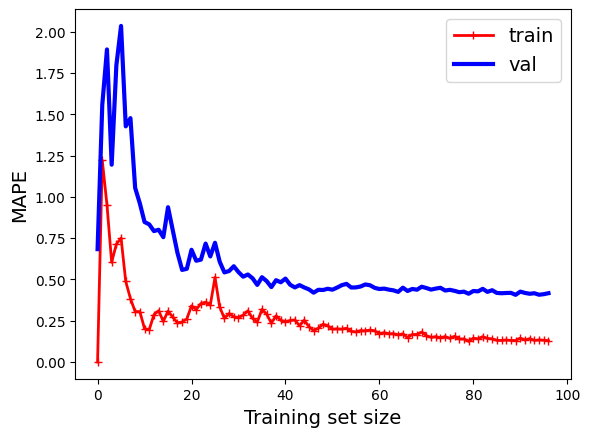

In [100]:
plot_learning_curves(rtr_reg, train_set, labels)

##### Cleaner data

In [76]:
crtr_reg = RandomForestRegressor()
crtr_reg.fit(train_set_clean, labels_clean)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mape": "neg_mean_absolute_percentage_error"
}
res = cross_validate(crtr_reg, train_set_clean, labels_clean, cv=10, scoring=scoring, return_train_score=True, n_jobs=-1)
mape_mean = -res["test_mape"]
rmse_scores = -res["test_rmse"]

In [77]:
display_scores(mape_mean)
display_scores(rmse_scores)

Model Performance
scores:  [0.2472775  0.29418975 0.26713047 0.26513492 0.27016405 0.30166341
 0.26827498 0.29254169 0.27524635 0.27261455]
mean:  0.275423767706594
standard deviation:  0.015450724629873984
Model Performance
scores:  [31872.49466454 38997.6934388  27814.8007828  24609.47291446
 24049.8862598  26409.09824848 26745.84388029 23446.22519484
 26719.84180336 27611.8688132 ]
mean:  27827.722600058354
standard deviation:  4352.151696139608


In [80]:
feature_importances = crtr_reg.feature_importances_
nums = final_pipeline.named_transformers_["nums"]
cats = final_pipeline.named_transformers_["cats"]
num_features = num_attributes
ohe = cats.named_steps["one-hot-encoder"]
cat_features = ohe.get_feature_names_out(cat_attributes).tolist()
feature_names = num_features + cat_features
sorted(zip(feature_importances, feature_names), reverse=True)

[(np.float64(0.4541863466537965), 'Years'),
 (np.float64(0.40374571787688285), 'Power_HP'),
 (np.float64(0.06541925275483379), 'Mileage_km'),
 (np.float64(0.01762594092616064), 'CO2_emissions'),
 (np.float64(0.016403067789180825), 'Vehicle_brand'),
 (np.float64(0.009656849931967967), 'Transmission_Automatic'),
 (np.float64(0.009233179292400273), 'Type_SUV'),
 (np.float64(0.005799072757905913), 'Transmission_Manual'),
 (np.float64(0.0032245868050358372), 'Type_sedan'),
 (np.float64(0.0024729879622800498), 'Type_minivan'),
 (np.float64(0.002373375220640763), 'Type_compact'),
 (np.float64(0.002101087796674001), 'Condition_New'),
 (np.float64(0.0019898326660601202), 'Type_station_wagon'),
 (np.float64(0.001866034058915255), 'Condition_Used'),
 (np.float64(0.001422645878318393), 'Type_coupe'),
 (np.float64(0.0012032170888926872), 'Type_city_cars'),
 (np.float64(0.0010779282557785226), 'Type_convertible'),
 (np.float64(0.0001988762842756778), 'Type_small_cars')]

##### Hyperparameters

In [24]:
def find_good_forestreg():
    params = {'bootstrap': [True, False],
            'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
            'max_features': [2, 3, 4, 5, 6, None],
            'min_samples_leaf': [1, 2, 4],
            'min_samples_split': [2, 5, 10],
            'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}
    forest_reg = RandomForestRegressor()

    random_search = RandomizedSearchCV(estimator=forest_reg, param_distributions=params,
                                    n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=3)

    random_search.fit(train_set, labels)
    print(random_search.best_params_)
    print(random_search.best_estimator_)
    #evaluate(random_search.best_estimator_, test_set, test_labels)

def find_better_forestreg():
    params = {
        'bootstrap': [True],
        'max_depth': [10], #'max_depth': [7, 10, 13],
        'max_features': [10], #'max_features': [10, 15, None],
        'min_samples_leaf': [1, 2],
        'min_samples_split': [4, 5, 6],
        'n_estimators': [1300, 1400, 1500]
        }
    forest_reg = RandomForestRegressor()

    grid_search = GridSearchCV(estimator=forest_reg, param_grid=params,
                                  cv=3, n_jobs=-1, verbose=3)
    grid_search.fit(train_set, labels)
    print(grid_search.best_params_)
    print(grid_search.best_estimator_)
    #evaluate(grid_search.best_estimator_, test_set, test_labels)

In [36]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 1300, 1600)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 5, 10, 15, None])
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42,
        n_jobs=-1
    )

    # score = cross_val_score(model, train_set, labels, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    # rmse_score = float(np.mean(np.sqrt(-score)))
    #cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    preds = cross_val_predict(model, train_set, labels, cv=5, n_jobs=-1)
    rmse_score = rmse(train_set, preds)
    mape_score = mape(labels, preds)
    trial.set_user_attr("rmse", float(rmse_score))
    trial.set_user_attr("mape", float(1 - mape_score))
    #return float(rmse_score)
    return float(1 - mape_score)

In [37]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler(seed=42))
study.optimize(objective, n_trials=20)

[I 2025-12-16 15:04:09,091] A new study created in memory with name: no-name-4cc30809-ea67-4750-84a0-48d7ddeb4210
[W 2025-12-16 15:04:59,291] Trial 0 failed with parameters: {'n_estimators': 1412, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 10, 'bootstrap': False} because of the following error: ValueError('y_true and y_pred have different number of output (19!=1)').
Traceback (most recent call last):
  File "d:\matura\komis\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\mikołaj\AppData\Local\Temp\ipykernel_5568\379008397.py", line 24, in objective
    rmse_score = rmse(train_set, preds)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "d:\matura\komis\.venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "d:\matura\komis\.venv\Lib\site-pack

ValueError: y_true and y_pred have different number of output (19!=1)

In [ ]:
best_params = study.best_params
print(f"Best Hyperparameters: {best_params}")
best_score = study.best_value
print(f"Best Accuracy: {best_score:.3f}")

In [20]:
#best_params = {'bootstrap': True, 'max_depth': 10, 'max_features': 10, 'n_estimators': 1500, 'min_samples_leaf': 1, 'min_samples_split': 4}
best_params = {'n_estimators': 1543, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 10, 'bootstrap': True}

forest_reg = RandomForestRegressor(**best_params)
#forest_reg.fit(train_set, labels)
#evaluate(forest_reg, test_set, test_labels)
fit_and_get_scores(forest_reg, train_set, labels)

array([33707.45943859, 46423.13352849, 30139.70789936, 34246.28537678,
       29518.85117118, 36918.00220795, 35843.93840237, 25808.03983041,
       26227.71560495, 32524.49621918])

In [ ]:


#best_params = {'n_estimators': 1400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'bootstrap': True}
#best_params = {'bootstrap': True, 'max_depth': 10, 'max_features': 10, 'n_estimators': 1500, 'min_samples_leaf': 1, 'min_samples_split': 4}
best_params = {'n_estimators': 1543, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 10, 'bootstrap': True}

base = RandomForestRegressor(**best_params)
model = TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1)
#model.fit(train_set, labels)
fit_and_get_scores(model, train_set, labels)

Model Performance
Accuracy = 0.76%.
final_rmse:  30975.81908285399


### LGBMRegressor

In [ ]:
from lightgbm import LGBMRegressor

def find_good_lgbmreg():
    params = {
        'n_estimators': [300, 500, 800, 1200, 2000],
        'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
        'num_leaves': [15, 31, 63, 127],
        'max_depth': [-1, 5, 7, 9, 12],
        'min_child_samples': [10, 20, 30, 50, 100],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'reg_alpha': [0.0, 0.1, 0.5, 1.0],
        'reg_lambda': [0.0, 0.1, 0.5, 1.0]
    }

    lgbmreg = LGBMRegressor(objective='regression')

    lgbmreg_random_search = RandomizedSearchCV(estimator=lgbmreg, param_distributions=params,
                                    n_iter=15, cv=5, random_state=42, n_jobs=-1, verbose=3)

    lgbmreg_random_search.fit(train_set, labels)
    print(lgbmreg_random_search.best_params_)
    print(lgbmreg_random_search.best_estimator_)
    evaluate(lgbmreg_random_search.best_estimator_, test_set, test_labels)

#find_good_lgbmreg()

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000958 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 807
[LightGBM] [Info] Number of data points in the train set: 12265, number of used features: 19
[LightGBM] [Info] Start training from score 64301.336078
{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
LGBMRegressor(colsample_bytree=0.6, learning_rate=0.05, n_estimators=500,
              num_leaves=15, objective='regression', reg_alpha=0.1,
              reg_lambda=1.0, subsample=0.9)


In [ ]:
best_params = {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

lgbmreg = RandomForestRegressor(**best_params)
lgbmreg.fit(train_set, labels)
print()

In [ ]:
evaluate(lgbmreg, test_set, test_labels)

Model Performance
Accuracy = 0.72%.
final_rmse:  31758.162394431864


d:\matura\komis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\matura\komis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### HistGradientBoostingRegressor

In [208]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgbreg_params = {
    "max_iter": [100, 200, 500, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_leaf_nodes": [31, 63, 127, None],
    "l2_regularization": [0.0, 0.1, 0.5, 1.0],
    "max_bins": [16, 32, 64, 128, 255],
    "categorical_features": [None],
}

hgbreg = HistGradientBoostingRegressor()

hgbreg_random_search = RandomizedSearchCV(estimator=hgbreg, param_distributions=hgbreg_params,
                                   n_iter=15, cv=5, random_state=42, n_jobs=-1, verbose=3)

hgbreg_random_search.fit(train_set, labels)
print(hgbreg_random_search.best_params_)
print(hgbreg_random_search.best_estimator_)
evaluate(hgbreg_random_search.best_estimator_, test_set, test_labels)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
{'min_samples_leaf': 50, 'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 5, 'max_bins': 255, 'learning_rate': 0.01, 'l2_regularization': 0.1, 'categorical_features': None}
HistGradientBoostingRegressor(categorical_features=None, l2_regularization=0.1,
                              learning_rate=0.01, max_depth=5, max_iter=1000,
                              max_leaf_nodes=127, min_samples_leaf=50)
Model Performance
Accuracy = 0.71%.
final_rmse:  30801.396996461255


In [207]:
evaluate(hgbreg_random_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.65%.
final_rmse:  30663.968449787688


### SVM

In [191]:
from sklearn.svm import SVR

def find_good_svm():
    params = {
        'C': [10, 100, 1000, 2000, 2500, 3000, 3500, 4000],
        'epsilon': [0.5, 0.7, 1.0, 1.5, 2, 2.5, 3, 3.5],
        'gamma': ['scale', 'auto', 0.005, 0.01, 0.05, 0.1, 0.2, 0.5],
        'kernel': ['rbf']
    }
    svm = SVR()

    svm_random_search = RandomizedSearchCV(estimator=svm, param_distributions=params,
                                    n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=3)

    svm_random_search.fit(train_set, labels)
    print(svm_random_search.best_params_)
    print(svm_random_search.best_estimator_)
    evaluate(svm_random_search.best_estimator_, test_set, test_labels)

find_good_svm()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 3, 'C': 4000}
SVR(C=4000, epsilon=3, gamma='auto')


In [259]:
best_params = {'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 3, 'C': 4000}

svmreg = SVR(**best_params)
svmreg.fit(train_set_clean, labels_clean)
print()

In [260]:
evaluate(svmreg, test_set, test_labels)

Model Performance
Accuracy = 0.73%.
final_rmse:  56605.14005747156


In [194]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

params = {
    'C': [4000, 4500, 5000],
    'epsilon': [3, 3.5, 4, 4.5],
    'gamma': ['auto'],
    'kernel': ['rbf']
}
svm = SVR()

grid_search = GridSearchCV(estimator=svm, param_grid=params,
                            cv=3, n_jobs=-1, verbose=3,
                            return_train_score=True)

grid_search.fit(train_set, labels)
print(grid_search.best_params_)
print(grid_search.best_estimator_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'C': 5000, 'epsilon': 3, 'gamma': 'auto', 'kernel': 'rbf'}
SVR(C=5000, epsilon=3, gamma='auto')


In [195]:
evaluate(grid_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.69%.
final_rmse:  56871.59195511421
